<a href="https://colab.research.google.com/github/hirenpatel1404/AI_lab/blob/main/Lesson_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset Exploratory Data Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset

In [3]:
# Load the Titanic dataset from the uploaded CSV file
df = pd.read_csv("Titanic-Dataset.csv")
# Confirm it loaded by checking the shape (rows, columns)
print("Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)

Dataset loaded successfully!
Shape (rows, columns): (891, 12)


### Task 1 Interpretation
I loaded the Titanic dataset using `pd.read_csv()`, which reads a CSV file into a DataFrame.
The dataset has **891 rows** (passengers) and **12 columns** (features like Name, Age, Sex, Fare, and Survived).

In [4]:
# Display the FIRST 5 rows — see what the data looks like at the top
print("First 5 rows:")
print(df.head())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [5]:
# Display the LAST 5 rows — check the bottom of the data
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [6]:
# Display the DATA TYPE of each column (text, integer, float, etc.)
print("\nData types:")
print(df.dtypes)


Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:

# Display SUMMARY STATISTICS for the numeric columns
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


### Task 2 Interpretation
I inspected the dataset using four commands:
- **`head()`** shows the first 5 rows — a quick look at the data.
- **`tail()`** shows the last 5 rows — confirms the data runs all the way through.
- **`dtypes`** shows each column's type (e.g. Age is a float, Name is text/object).
- **`describe()`** gives summary statistics (count, mean, min, max, quartiles) for the numeric columns.
- **`describe()`** with include='all' shows EVERY column — numbers AND text

**Key observations:**
- The average passenger age is about **29.7 years**.
- Fares vary a lot — from **0** up to about **512**, showing a big gap between cheap and expensive tickets.
- `describe()` shows Age has only **714 counts** (not 891), which means some ages are **missing** — I'll fix that in Task 3.

# Task 3: Clean and preprocess the data

In [15]:
# Create 'PclassCategory' from 'Pclass' ---
# Pclass is 1, 2, 3 (numbers). Turn them into readable labels.
df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

In [16]:
# Create 'CabinCategory' from 'Cabin'
# Cabin has values like "C85". We take just the first letter (the deck).
# Missing cabins become 'Unknown'.
df['CabinCategory'] = df['Cabin'].astype(str).str[0]
df['CabinCategory'] = df['CabinCategory'].replace('n', 'Unknown')

In [19]:
# Create 'Family' feature from SibSp + Parch
# SibSp = siblings/spouses, Parch = parents/children. +1 includes the passenger.
df['Family'] = df['SibSp'] + df['Parch'] + 1
print("New columns added: PclassCategory, CabinCategory, Family")
print(df[['Pclass', 'PclassCategory', 'Cabin', 'CabinCategory', 'Family']].head())

New columns added: PclassCategory, CabinCategory, Family
   Pclass PclassCategory Cabin CabinCategory  Family
0       3          Third   NaN       Unknown       2
1       1          First   C85             C       2
2       3          Third   NaN       Unknown       1
3       1          First  C123             C       2
4       3          Third   NaN       Unknown       1


In [21]:
# Handle missing 'Age' values (fill with mean age)
mean_age = round(df['Age'].mean(), 1)
df['Age'] = df['Age'].fillna(mean_age)


In [22]:
df['Age'].isnull().sum()

np.int64(0)

### Task 3 Interpretation
I cleaned and prepared the data in four steps:
- **PclassCategory:** turned the class numbers (1, 2, 3) into readable labels (First, Second, Third) using `map()`.
- **CabinCategory:** took the first letter of each cabin (the deck level, e.g. "C85" → "C"). Missing cabins became "Unknown".
- **Age:** filled the 177 missing ages with the **mean age** (~29.7), so no rows are lost.
- **Family:** created a family-size feature by adding siblings/spouses (`SibSp`) + parents/children (`Parch`) + 1 for the passenger themselves.

After this, the Age column has **no missing values**, and the data is ready for analysis.

# Task 4: Identify specific data points

In [27]:
# Create a readable label from the Survived column (0/1 -> text)
df['SurvivedLabel'] = df['Survived'].map({0: 'Not Survived', 1: 'Survived'})
# Check it worked
print(df[['Name', 'Survived', 'SurvivedLabel']].head())

                                                Name  Survived SurvivedLabel
0                            Braund, Mr. Owen Harris         0  Not Survived
1  Cumings, Mrs. John Bradley (Florence Briggs Th...         1      Survived
2                             Heikkinen, Miss. Laina         1      Survived
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)         1      Survived
4                           Allen, Mr. William Henry         0  Not Survived


In [30]:
# Find passengers with the HIGHEST fare
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]
print("Passengers with the highest fare:")
print(highest_fare_passengers[['Name', 'Pclass', 'Fare', 'SurvivedLabel']])

Passengers with the highest fare:
                                   Name  Pclass      Fare SurvivedLabel
258                    Ward, Miss. Anna       1  512.3292      Survived
679  Cardeza, Mr. Thomas Drake Martinez       1  512.3292      Survived
737              Lesurer, Mr. Gustave J       1  512.3292      Survived


In [29]:
# Find passengers with the LARGEST family
largest_family_passengers = df[df['Family'] == df['Family'].max()]
print("\nPassengers with the largest family:")
print(largest_family_passengers[['Name', 'Pclass', 'Family', 'SurvivedLabel']])


Passengers with the largest family:
                                  Name  Pclass  Family SurvivedLabel
159         Sage, Master. Thomas Henry       3      11  Not Survived
180       Sage, Miss. Constance Gladys       3      11  Not Survived
201                Sage, Mr. Frederick       3      11  Not Survived
324           Sage, Mr. George John Jr       3      11  Not Survived
792            Sage, Miss. Stella Anna       3      11  Not Survived
846           Sage, Mr. Douglas Bullen       3      11  Not Survived
863  Sage, Miss. Dorothy Edith "Dolly"       3      11  Not Survived


### Task 4 Interpretation
I used filtering to find specific passengers, and also added a readable survival label.

**Survival label:** I created a `SurvivedLabel` column that turns the 0/1 values into
readable text ("Survived" / "Not Survived") using `map()`. This makes the results easier
to read than raw numbers.

**Highest fare:** using `df['Fare'].max()`, the most expensive ticket was about **$512**,
paid by first-class passengers — and they all survived.

**Largest family:** using the `Family` feature, the biggest group had **11 members**
travelling together (the Sage family, third class) — and they mostly did not survive.

**Insight:** the contrast stands out — wealthy first-class passengers survived, while the
large third-class family did not. This early hint that class and money affected survival
sets up the survival analysis in Task 8.

#Task 5: Pandas Series and DataFrame

In [31]:
# Create a Pandas Series of passenger names
# One column of data = a Series
names_series = df['Name']
print("Passenger names (Series) — first 5:")
print(names_series.head())
print("Type:", type(names_series))

Passenger names (Series) — first 5:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object
Type: <class 'pandas.core.series.Series'>


In [32]:
# Create a DataFrame of names AND ages
# Two columns = a DataFrame (note the double brackets)
names_ages_df = df[['Name', 'Age']]
print("\nNames and Ages (DataFrame) — first 5:")
print(names_ages_df.head())


Names and Ages (DataFrame) — first 5:
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0


In [33]:
# Slice to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df['Age'] > 50]
print(f"\nPassengers older than 50: {len(older_passengers)} found")
print(older_passengers.head())


Passengers older than 50: 64 found
                                Name   Age
6            McCarthy, Mr. Timothy J  54.0
11          Bonnell, Miss. Elizabeth  58.0
15  Hewlett, Mrs. (Mary D Kingcome)   55.0
33             Wheadon, Mr. Edward H  66.0
54    Ostby, Mr. Engelhart Cornelius  65.0


### Task 5 Interpretation
This task showed the difference between a Series and a DataFrame:
- **Series:** selecting one column (`df['Name']`) gives a **Series** — a single column of data.
- **DataFrame:** selecting two columns (`df[['Name', 'Age']]`) gives a **DataFrame** — a small table.
- **Slicing:** I filtered for passengers older than 50 using a condition, which returned only the rows where Age > 50.

**Key point:** single brackets `[ ]` give one column (a Series); double brackets `[[ ]]` give a table (a DataFrame).

# Task 6: Introduce multi-indexing

In [34]:
# Group by TWO columns (Sex and Pclass) — this creates a multi-index
# .agg() lets us calculate several statistics at once for each group
multi_index_df = df.groupby(['Sex', 'Pclass']).agg({
    'Survived': 'mean',
    'Age': 'mean',
    'Fare': 'mean'
})

print("Multi-index DataFrame (grouped by Sex and Pclass):")
print(multi_index_df)

Multi-index DataFrame (grouped by Sex and Pclass):
               Survived        Age        Fare
Sex    Pclass                                 
female 1       0.968085  34.141489  106.125798
       2       0.921053  28.748684   21.970121
       3       0.500000  24.068750   16.118810
male   1       0.368852  39.287869   67.226127
       2       0.157407  30.653981   19.741782
       3       0.135447  27.372392   12.661633


### Task 6 Interpretation
I created a multi-index DataFrame by grouping on **two** columns at once — `Sex` and `Pclass`.
- A **multi-index** means the table has two levels of row labels (Sex on the outside, Pclass inside).
- I used `.agg()` to calculate the average survival rate, age, and fare for each Sex + Class group.

**Key insight:** survival rates differ hugely by group — for example, **first-class women** had a very high survival rate, while **third-class men** had a very low one. This shows that both sex and class together strongly affected survival.

#Task 7: Visualizations

#Histogram of passenger ages

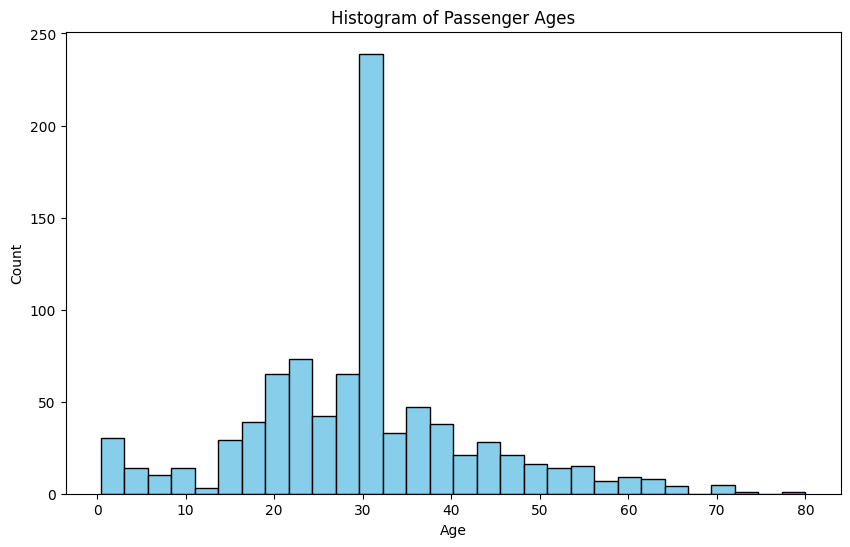

In [35]:

plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Interpretation: Age Histogram
The histogram shows most passengers were **young adults (20–40)**. There's a tall spike
around age 30 — that's partly because we filled 177 missing ages with the mean (~29.7),
which stacks up at that value. Fewer passengers were very young children or elderly.

#Bar plot of survival rate by class

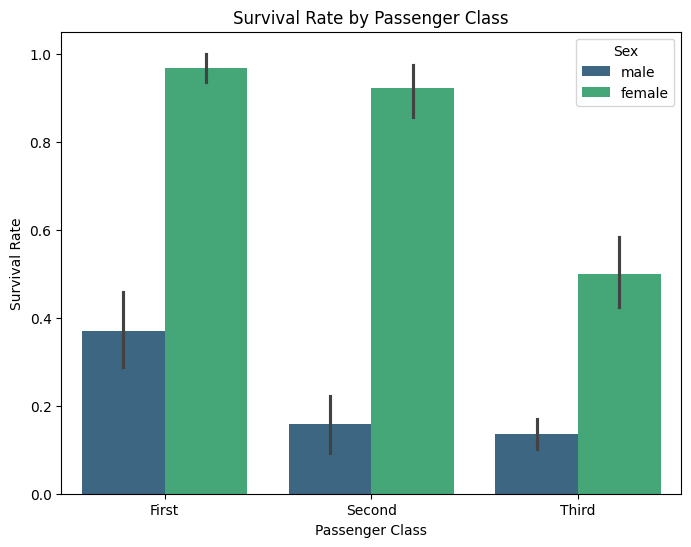

In [37]:
plt.figure(figsize=(8, 6))
sns.barplot(x='PclassCategory', y='Survived', data=df,
            order=['First', 'Second', 'Third'], palette='viridis', hue='Sex')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

### Interpretation: Survival by Class and Sex
Adding `hue='Sex'` splits each class into male and female bars.
The result is striking: **women survived at much higher rates than men in every class.**
First-class women had near-total survival, while third-class men had the lowest.
This shows sex and class *together* shaped survival — matching the multi-index table in Task 6.

#Correlation heatmap

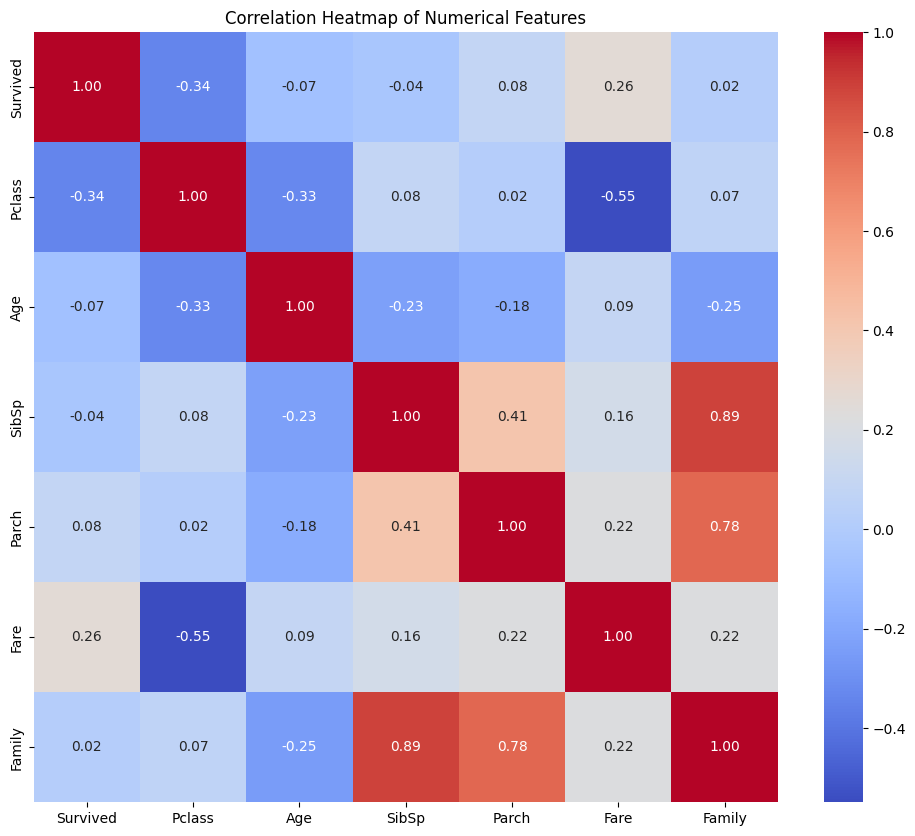

In [38]:
plt.figure(figsize=(12, 10))
# Pick only numeric columns for the correlation
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Interpretation: Correlation Heatmap
The heatmap shows how numeric features relate (from -1 to +1):
- **Fare and Survived** are positively linked — higher fares meant better survival chances.
- **Pclass and Survived** are negatively linked — remember class 3 is the *lowest*, so a
  higher class number means lower survival.
- **SibSp, Parch, and Family** are strongly linked to each other (Family is built from them).

#Pair plot

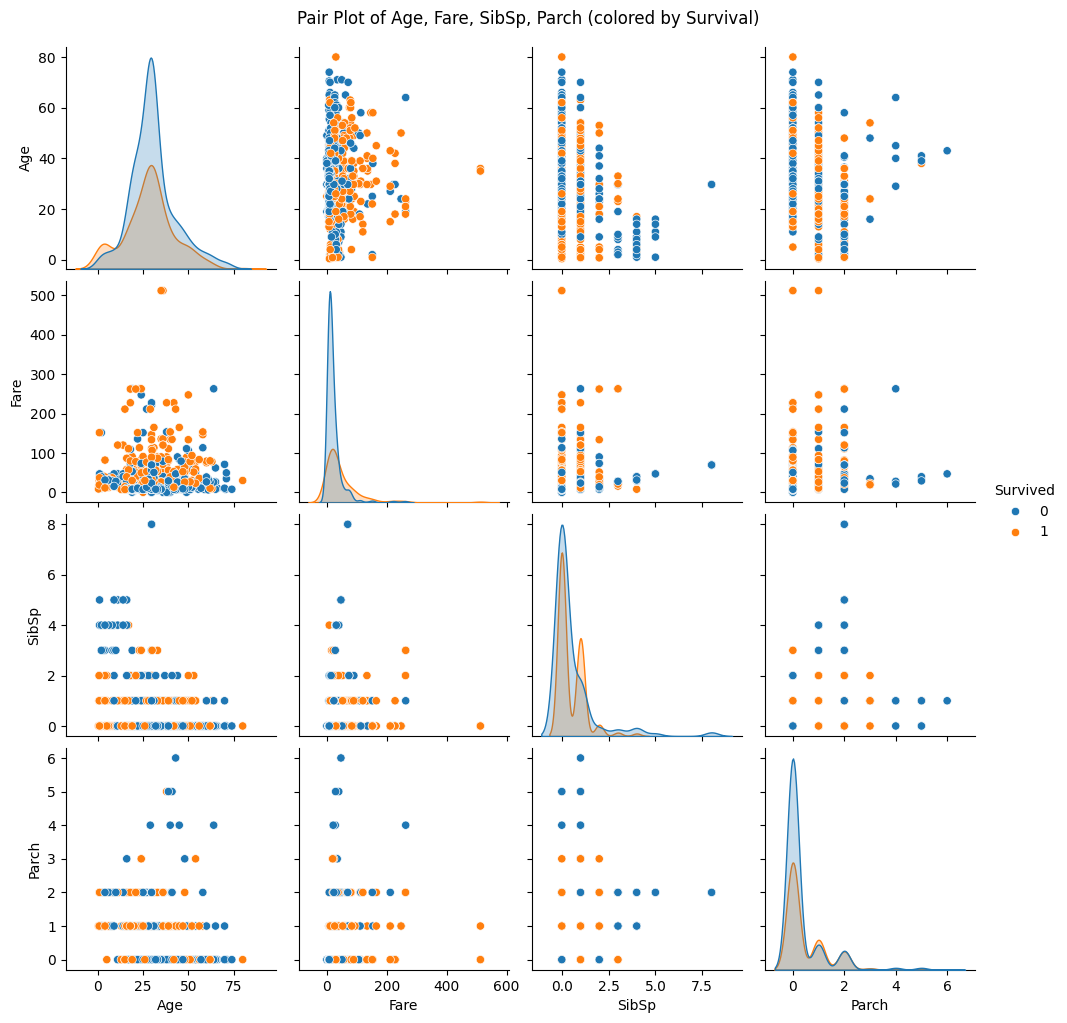

In [39]:
sns.pairplot(df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']], hue='Survived')
plt.suptitle('Pair Plot of Age, Fare, SibSp, Parch (colored by Survival)', y=1.02)
plt.show()

### Interpretation: Pair Plot
The pair plot compares Age, Fare, SibSp, and Parch, colored by survival (0 vs 1).
- Passengers who paid **higher fares** (top of the Fare charts) show more survivors.
- Most passengers had small family numbers (points cluster near 0 for SibSp/Parch).
This gives a quick visual overview of how these features relate to survival all in one grid.

# Task 8: Analyze survival rates

In [40]:
# Survival rate by SEX
# Survived is 0/1, so the mean = the survival rate (proportion who survived)
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival rate by sex:")
print(survival_by_sex)

# Survival rate by CLASS
survival_by_class = df.groupby('PclassCategory')['Survived'].mean()
print("\nSurvival rate by passenger class:")
print(survival_by_class)

Survival rate by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
PclassCategory
First     0.629630
Second    0.472826
Third     0.242363
Name: Survived, dtype: float64


### Task 8 Interpretation
I calculated survival rates using `groupby` + `mean()` (since Survived is 0/1, the mean is the survival rate).

**By sex:**
- Female: ~74% survived
- Male: ~19% survived
Women were far more likely to survive — strong evidence of "women and children first."

**By class:**
- First: ~63% survived
- Second: ~47% survived
- Third: ~24% survived
Higher class meant a better chance of survival.

**Overall:** both sex and class had a big impact, with **first-class women** the most likely
to survive and **third-class men** the least — consistent with the charts and the multi-index table.

# Task 9: Analyze age distribution

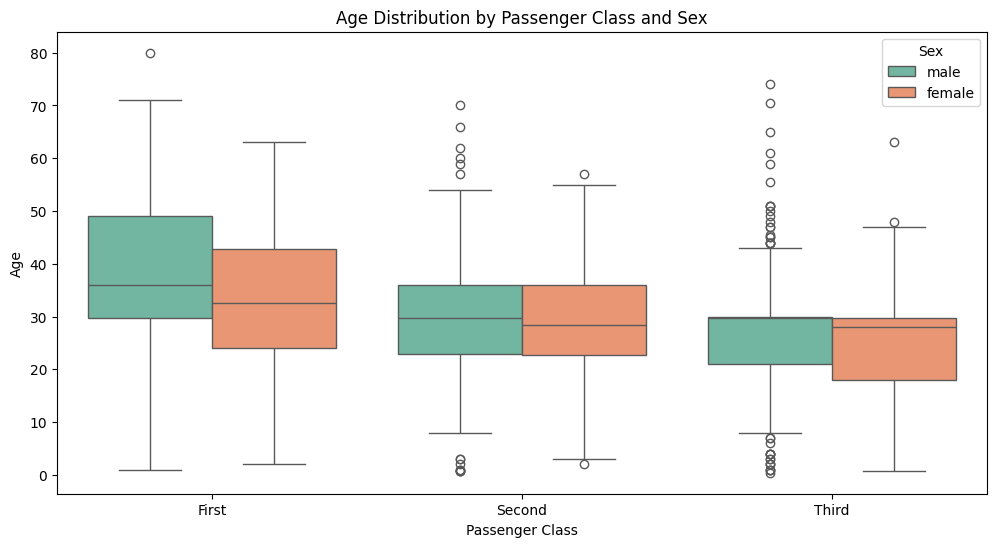

In [41]:
plt.figure(figsize=(12, 6))
# x = class, y = age, split each class by sex using hue
sns.boxplot(x='PclassCategory', y='Age', hue='Sex', data=df,
            order=['First', 'Second', 'Third'], palette='Set2')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(title='Sex')
plt.show()

### Task 9 Interpretation: Age by Class and Sex
The box plot shows how ages are spread across class and sex.
- **First-class passengers were older on average** (median around 35–40), likely wealthier,
  more established people.
- **Third-class passengers were younger** (median around 25), often young people travelling
  for a new life.
- The dots above/below the boxes are **outliers** — a few unusually old or young passengers.

This shows class was linked to age — older, wealthier passengers travelled first class.

# Task 10: Analyze fare distribution

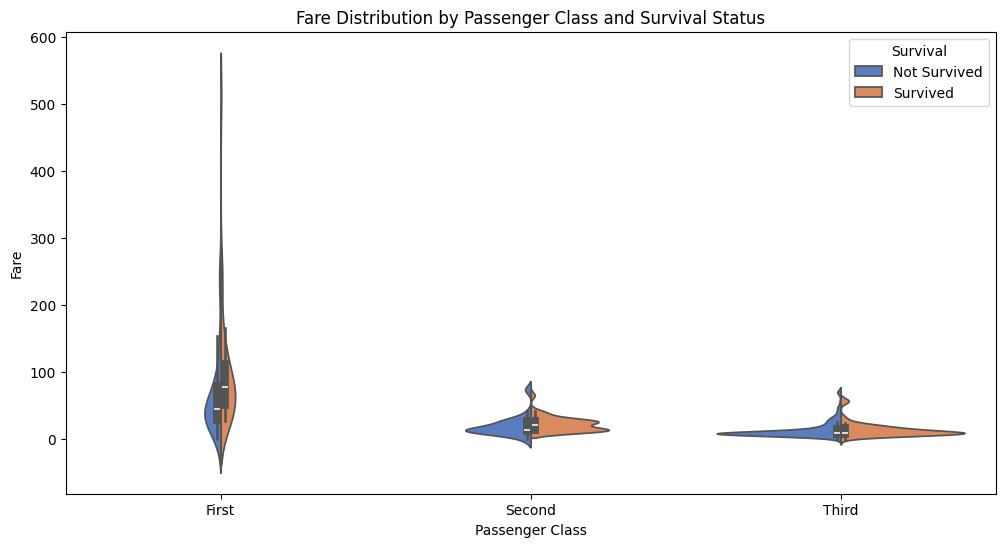

In [42]:
plt.figure(figsize=(12, 6))
# x = class, y = fare, split each class by survival using hue
sns.violinplot(x='PclassCategory', y='Fare', hue='SurvivedLabel', data=df,
               order=['First', 'Second', 'Third'], palette='muted', split=True)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.legend(title='Survival')
plt.show()

### Task 10 Interpretation: Fare by Class and Survival
The violin plot shows how fares were spread across classes, split by survival.
- **First-class fares were much higher and more spread out**, while second and third class
  fares were low and tightly clustered.
- Within first class, survivors tended to have paid **higher fares** than non-survivors.
- The wide shape of the violin shows where most fares fell — the fatter the section, the
  more passengers paid around that price.

**Insight:** higher fares (linked to higher class) generally meant a better survival chance,
reinforcing the class-and-survival pattern seen throughout the analysis.

In [43]:

print("EDA tasks completed.")

EDA tasks completed.


## EDA Summary — Key Insights

After exploring the Titanic dataset, the main findings are:

1. **Sex was the strongest survival factor** — about **74% of women survived** vs only **19% of men**, reflecting "women and children first."

2. **Class mattered a lot** — survival dropped from **63% (first class)** to **47% (second)** to **24% (third)**. Wealthier passengers had better chances.

3. **Sex and class combined** had the biggest effect — **first-class women (~97%)** survived at the highest rate, while **third-class men (~14%)** the lowest.

4. **Fare linked to survival** — higher fares (tied to higher class) generally meant better survival odds.

5. **Age patterns** — first-class passengers were older on average; third-class were younger.

6. **Data cleaning notes** — 177 missing ages were filled with the mean, and 687 missing cabins were labelled "Unknown." These choices let me keep all 891 rows for analysis.

**Overall:** survival on the Titanic was strongly shaped by **sex, class, and fare** — not random. The analysis shows clear social patterns in who survived.